In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Base de dados carregada para a análise do que será útil.

In [ ]:
fies_df_2021_2 = pd.read_csv("relatorio_inscricao_dados_abertos_fies_22021.csv", sep=";", encoding="latin-1")


C:\Users\arfra\AppData\Local\Temp\ipykernel_9604\3536249008.py:1: DtypeWarning: Columns (49) have mixed types. Specify dtype option on import or set low_memory=False.
  fies_df_2021_2 = pd.read_csv("relatorio_inscricao_dados_abertos_fies_22021.csv", sep=";", encoding="latin-1")


In [3]:
fies_df_2021["Situação Inscrição Fies"].value_counts()

Situação Inscrição Fies
NÃO CONTRATADO                           115785
LISTA DE ESPERA                           51312
CONTRATADA                                22443
OPÇÃO NÃO CONTRATADA                      21048
PARTICIPACAO CANCELADA PELO CANDIDATO     16435
PRÉ-SELECIONADO                            7436
INSCRIÇÃO POSTERGADA                       1904
REJEITADA PELA CPSA                        1602
Name: count, dtype: int64

Retirada de linahs vazias

In [3]:
fies_df_2021 = fies_df_2021.dropna(subset=["Área do conhecimento", "Subárea do conhecimento", "Nome do curso", "Turno", "Grau", "Conceito"])

In [ ]:
def taxa_de_evasao (df_atual, df_anterior):
    df_atual = pd.readcsv(df_atual, sep=';', encoding='latin1', low_memory=False)
    df_anterior = pd.readcsv(df_anterior, sep=';', encoding='latin1', low_memory=False)

    COLUNAS_NECESSARIAS = [
        "ID do estudante",
        "Situação Inscrição Fies",
        "UF",
        "Área do conhecimento",
        "Nome da IES",
        "Código do curso",
    ]

    contratados_base = df_atual[
        df_atual["Situação Inscrição Fies"] == "CONTRATADA"
    ].drop_duplicates(subset="ID do estudante").copy()
    
    contratados_seguinte = df_anterior[
        df_anterior["Situação Inscrição Fies"] == "CONTRATADA"
    ].drop_duplicates(subset="ID do estudante").copy()
    
    fluxo = contratados_base.merge(
        contratados_seguinte[["ID do estudante"]],
        on="ID do estudante",
        how="left",
        indicator=True,
    )
    
    # both       -> permanece contratado no ano seguinte
    # left_only  -> não aparece mais como contratado (não-permanência)
    fluxo["STATUS"] = fluxo["_merge"].map({
        "both": "Permanece",
        "left_only": "Nao_permanece",
    })
    fluxo = fluxo.drop(columns="_merge")

    total_base = len(fluxo)
    nao_permanece = (fluxo["STATUS"] == "Nao_permanece").sum()
    taxa_evasao = (nao_permanece / total_base) * 100

    return taxa_evasao

In [5]:
fies_df_2021.isna().sum()

Ano do processo seletivo                     0
Semestre do processo seletivo                0
Classificação                                0
Sexo                                         0
Data de Nascimento                           0
UF de residência                             0
Municipio de residência                      0
Etnia/Cor                                    0
Pessoa com deficiência?                      0
Concluiu ensino médio escola pública         0
Ano conclusão ensino médio                   0
Concluiu curso superior?                     0
Beneficiado pelo Creduc ou Fies              0
Professor rede pública ensino?               0
Nº de membros Grupo Familiar                 0
Renda familiar mensal bruta              30275
Renda mensal bruta per capita                0
Região grupo de preferência                  0
UF                                           0
Cod.Microrregião                             0
Microrregião                                 0
Cod.Mesorregi

In [6]:
print(fies_df_2021["Região grupo de preferência"].value_counts().head(10))

Região grupo de preferência
SUDESTE         85775
NORDESTE        82493
NORTE           30342
CENTRO-OESTE    19804
SUL             19551
Name: count, dtype: int64


In [7]:
print(fies_df_2021["UF de residência"].value_counts().head(10))

UF de residência
SP    33945
MG    28299
BA    19242
RJ    17727
CE    17143
PA    13560
PE    12339
MA    10921
PR     9557
GO     8755
Name: count, dtype: int64


In [8]:
print(fies_df_2021["UF"].value_counts().head(10))

UF
SÃO PAULO         35374
MINAS GERAIS      28276
RIO DE JANEIRO    18279
BAHIA             17958
CEARÁ             16220
PARÁ              13415
PERNAMBUCO        11860
PARANÁ            10973
PARAÍBA            9816
MARANHÃO           9121
Name: count, dtype: int64


In [9]:
print(fies_df_2021["Etnia/Cor"].value_counts().head(10))

Etnia/Cor
PARDA       108934
BRANCA       94869
PRETA        28431
AMARELA       4974
INDÍGENA       757
Name: count, dtype: int64


In [10]:
print(fies_df_2021["Municipio de residência"].value_counts().head(10))

Municipio de residência
SÃO PAULO         9882
RIO DE JANEIRO    7203
BRASÍLIA          6529
MANAUS            6073
FORTALEZA         5999
BELÉM             5644
SALVADOR          4900
BELO HORIZONTE    4400
SÃO LUÍS          4081
TERESINA          3452
Name: count, dtype: int64


In [11]:
print(fies_df_2021["Subárea do conhecimento"].value_counts().head(10))

Subárea do conhecimento
MEDICINA                                                                                   55713
ENFERMAGEM, FISIOTERAPIA, FARMÁCIA, NUTRIÇÃO E CURSOS RELACIONADOS                         51630
DIREITO, COMÉRCIO EXTERIOR, BIBLIOTECONOMIA E CURSOS RELACIONADOS                          31954
ODONTOLOGIA, QUIROPRAXIA, FÍSICA MÉDICA E NATUROLOGIA                                      20223
CIÊNCIAS SOCIAIS, POLÍTICAS, ECONÔMICAS E CONTÁBEIS, PSICOLOGIA E SECRETARIADO             19296
ADMINISTRAÇÃO, ADMINISTRAÇÃO PÚBLICA, GESTÃO, LOGÍSTICA, NEGÓCIOS E CURSOS RELACIONADOS     9607
MEDICINA VETERINÁRIA                                                                        9134
ENGENHARIA CIVIL E AMBIENTAL, ARQUITETURA E CURSOS RELACIONADOS                             8291
CIÊNCIAS BIOLÓGICAS (BEL), BIOMEDICINA, BIOTECNOLOGIA E CURSOS RELACIONADOS                 5771
CIÊNCIA DA COMPUTAÇÃO E SISTEMAS DE INFORMAÇÃO E CURSOS RELACIONADOS                        4326
Name: 

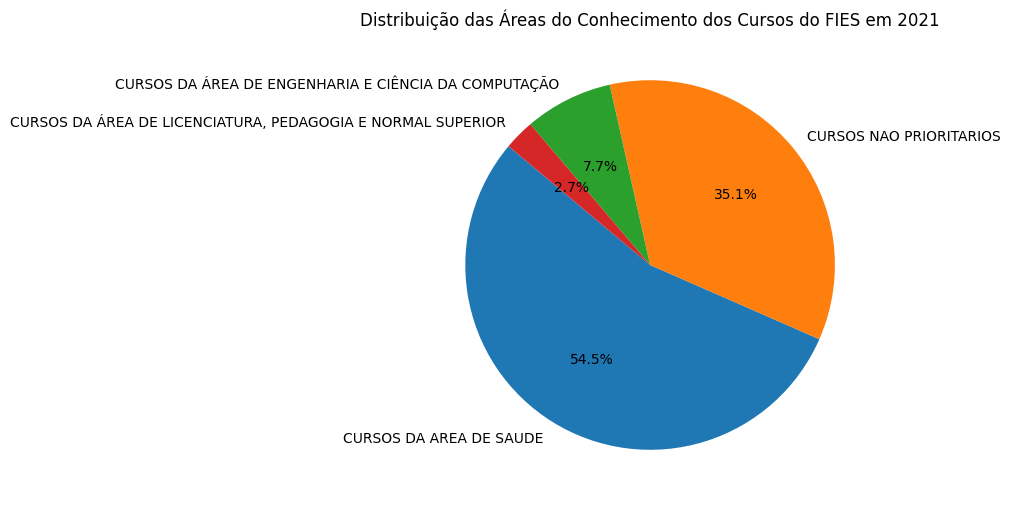

In [12]:
plt.figure(figsize=(10, 6))
# Gráfico de pizza
fies_df_2021["Área do conhecimento"].value_counts().plot.pie(autopct='%1.1f%%', startangle=140)
plt.title('Distribuição das Áreas do Conhecimento dos Cursos do FIES em 2021')
plt.ylabel('')
plt.show()

In [13]:
print(fies_df_2021["Nome do curso"].value_counts().head(10))

Nome do curso
MEDICINA                55711
DIREITO                 31819
ENFERMAGEM              22954
ODONTOLOGIA             20185
PSICOLOGIA              14889
FISIOTERAPIA            12587
FARMÁCIA                 9131
MEDICINA VETERINÁRIA     9096
NUTRIÇÃO                 6959
ADMINISTRAÇÃO            5791
Name: count, dtype: int64


In [14]:
print(fies_df_2021["Turno"].value_counts())

Turno
NOTURNO       110640
INTEGRAL       64055
MATUTINO       55628
VESPERTINO      7642
Name: count, dtype: int64


In [15]:
print(fies_df_2021["Grau"].value_counts())

Grau
SEMESTRAL     233410
ANUAL           4345
TRIMESTRAL       210
Name: count, dtype: int64


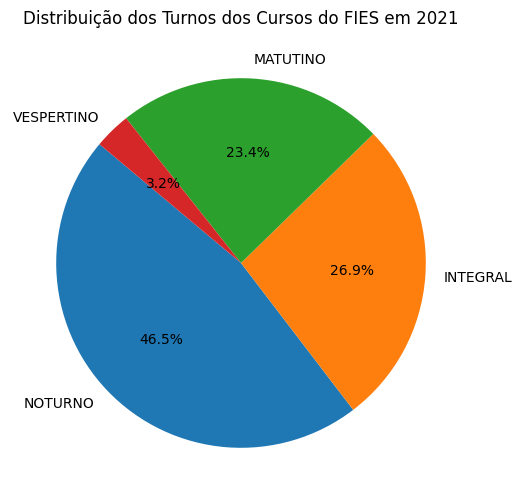

In [16]:
plt.figure(figsize=(10, 6))
fies_df_2021["Turno"].value_counts().plot.pie(autopct='%1.1f%%', startangle=140)
plt.title('Distribuição dos Turnos dos Cursos do FIES em 2021')
plt.ylabel('')
plt.show()

In [17]:
print(fies_df_2021["Conceito"].value_counts())

Conceito
4             140725
3              46131
5              31536
Autorizado     19573
Name: count, dtype: int64


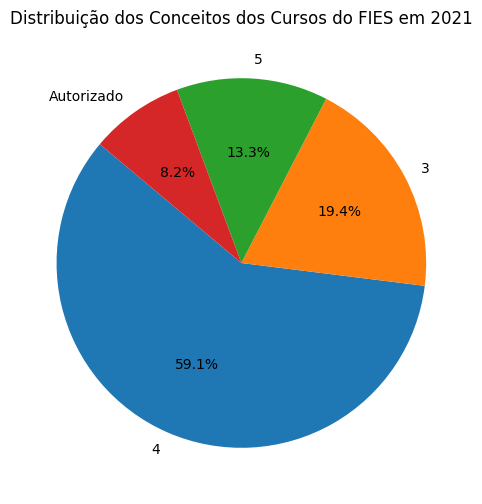

In [18]:
plt.figure(figsize=(10, 6))
fies_df_2021["Conceito"].value_counts().plot.pie(autopct='%1.1f%%', startangle=140)
plt.title('Distribuição dos Conceitos dos Cursos do FIES em 2021')
plt.ylabel('')
plt.show()

In [33]:
print(fies_df_2021["Concluiu ensino médio escola pública"].value_counts())

Concluiu ensino médio escola pública
SIM        171421
NÃO         53144
PARCIAL     13400
Name: count, dtype: int64


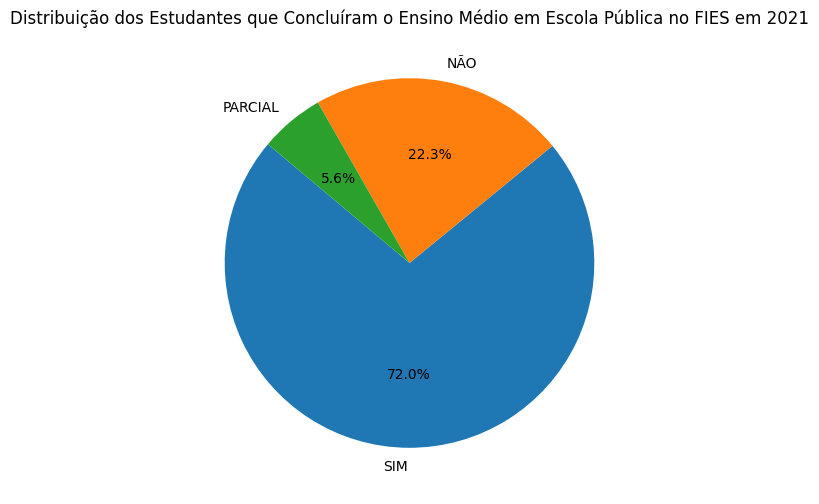

In [32]:

plt.figure(figsize=(10, 6))
fies_df_2021["Concluiu ensino médio escola pública"].value_counts().plot.pie(autopct='%1.1f%%', startangle=140)
plt.title('Distribuição dos Estudantes que Concluíram o Ensino Médio em Escola Pública no FIES em 2021')
plt.ylabel('')
plt.show()

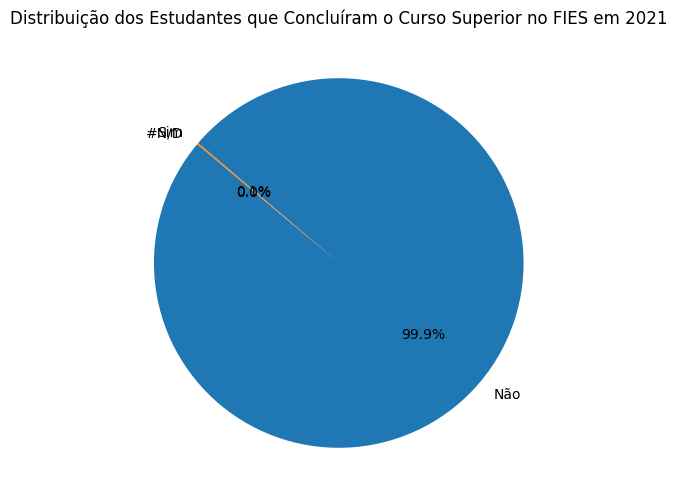

In [36]:

plt.figure(figsize=(10, 6))
fies_df_2021["Beneficiado pelo Creduc ou Fies"].value_counts().plot.pie(autopct='%1.1f%%', startangle=140)
plt.title('Distribuição dos Estudantes que Concluíram o Curso Superior no FIES em 2021')
plt.ylabel('')
plt.show()

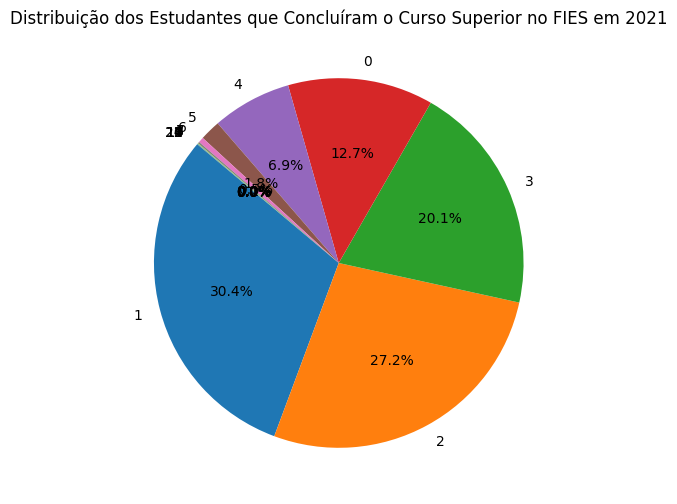

In [37]:
#Nº de membros Grupo Familiar
plt.figure(figsize=(10, 6))
fies_df_2021["Nº de membros Grupo Familiar"].value_counts().plot.pie(autopct='%1.1f%%', startangle=140)
plt.title('Distribuição dos Estudantes que Concluíram o Curso Superior no FIES em 2021')
plt.ylabel('')
plt.show()

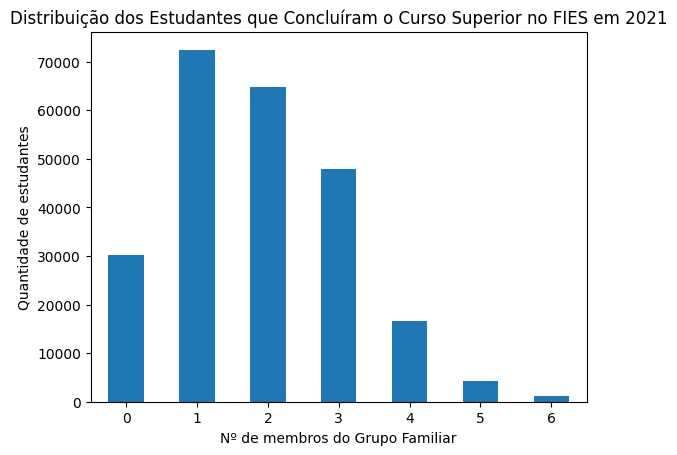

In [47]:
contagem = (
    fies_df_2021["Nº de membros Grupo Familiar"]
    .value_counts()
    .sort_index()
)

contagem = contagem[contagem.index <= 6]

contagem.plot.bar()

plt.title('Distribuição dos Estudantes que Concluíram o Curso Superior no FIES em 2021')
plt.xlabel('Nº de membros do Grupo Familiar')
plt.ylabel('Quantidade de estudantes')
plt.xticks(rotation=0)
plt.show()

In [19]:
print(fies_df_2021["Renda mensal bruta per capita"].dtype)

object


In [ ]:
fies_df_2021["Renda mensal bruta per capita"] = (
    fies_df_2021["Renda mensal bruta per capita"]
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

Após ver que o tipo estava dando erro, recorremos à ajuda da IA para corrigir.

In [18]:
media_renda = fies_df_2021["Renda mensal bruta per capita"]
print(np.mean(media_renda).round())
print(np.median(media_renda))
print(media_renda.mode()[0])

q1 = media_renda.quantile(0.25)
q3 = media_renda.quantile(0.75)
iqr = q3 - q1
print(q1)
print(q3)
print(iqr)
#calcular a média, mediana e moda da renda mensal bruta per capita
#media_renda = fies_df_2021["Renda mensal bruta per capita"]
media = np.mean(media_renda)
mediana = np.median(media_renda)
moda = media_renda.mode()[0]
print(f"Média: {media}, Mediana: {mediana}, Moda: {moda}")

1103.0
1000.0
1100.0
580.0
1400.0
820.0
Média: 1102.644335175341, Mediana: 1000.0, Moda: 1100.0


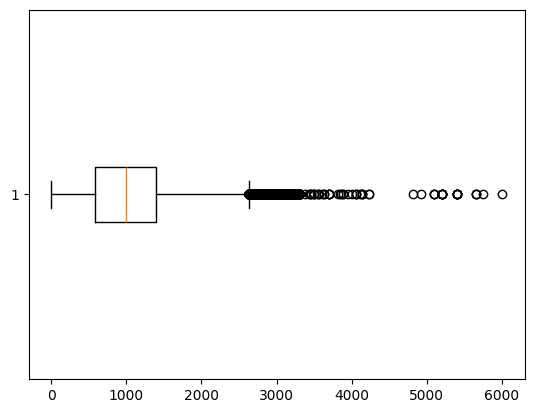

In [16]:
plt.boxplot(
    fies_df_2021["Renda mensal bruta per capita"].dropna(),
    vert=False
)
plt.show()

In [19]:
print(fies_df_2021["Média nota Enem"].value_counts())

Média nota Enem
524,4     66
515,84    64
532,38    63
502,76    61
544,12    58
          ..
795,32     1
730,04     1
780,56     1
621,04     1
784,94     1
Name: count, Length: 16314, dtype: int64


In [21]:
print(fies_df_2021["Média nota Enem"].dtype)

object


In [22]:
fies_df_2021["Média nota Enem"] = (
    fies_df_2021["Média nota Enem"]
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

In [23]:
media_enem = fies_df_2021["Média nota Enem"]
print(np.mean(media_enem).round())
print(np.median(media_enem))
print(media_enem.mode()[0])

q1 = media_enem.quantile(0.25)
q3 = media_enem.quantile(0.75)
iqr = q3 - q1
print(q1)
print(q3)
print(iqr)
#calcular a média, mediana e moda da renda mensal bruta per capita
#media_renda = fies_df_2021["Renda mensal bruta per capita"]
media_do_enem = np.mean(media_enem)
mediana_do_enem = np.median(media_enem)
moda_do_enem = media_enem.mode()[0]
print(f"Média: {media_do_enem}, Mediana: {mediana_do_enem}, Moda: {moda_do_enem}")

562.0
544.0
524.4
501.7
609.34
107.64000000000004
Média: 562.4714004160276, Mediana: 544.0, Moda: 524.4


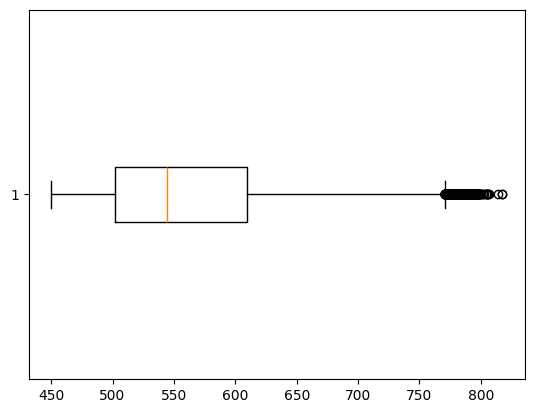

In [24]:
plt.boxplot(
    fies_df_2021["Média nota Enem"].dropna(),
    vert=False
)
plt.show()